## 5장 2강 : 프로토타입 기반 상속 및 클래스 모델링

생성자함수 만드는 법:
- 객체 상속
- this

---

생성자함수: 객체를 생성하는 함수
- 네이밍 관계: 첫글자를 대문자
- new 연산자

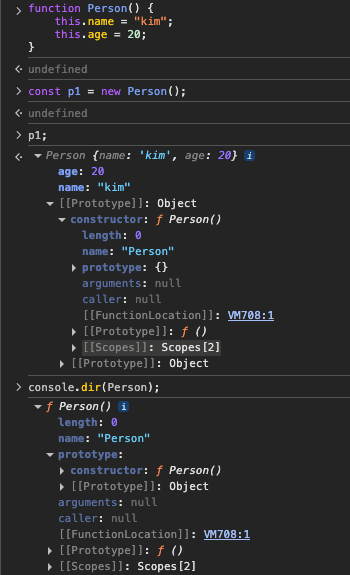

3. 생성자 함수가 객체를 만드는 과정

    1. 생성자 함수의 prototype 객체를 상속
    2. 생성자 함수의 this를 생성된 객체의 주소로 변경하고 호출

```javascript
function Person(name, age) {
  this.name = name;
  this.age = age;
}

const p1 = {};

p1.__proto__ = Person.prototype; // prototype 연결
Person.prototype.constructor.apply(p1, ["kim", 20]); // Person을 p1의 this로 실행

p1;
```

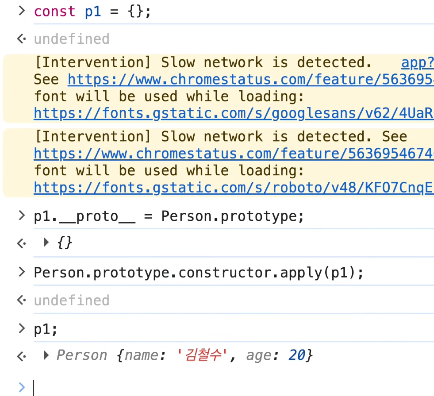

```javascript

function Person() {
    this.name = "김철수";
    this.age = 20;

    this.showInfo = function() { // 익명 함수
        console.log(this.name, this.age);
    }
}

const p1 = new Person();

const p2 = new Person();

p1 === p2; // false. 객체 만들 때마다 새로운 주소 생성
```

```javascript

function Person(name, age) {
    this.name = name;
    this.age = age;

    this.showInfo = function() { // 익명 함수
        console.log(this.name, this.age);
    }

}

const p1 = new Person("kim", 50); // class __init__ (python) 처럼 변수마다 다른 값 할당
const p2 = new Person("lee", 20);

p1.showInfo === p2.showInfo; // false
```
위 방법은 메모리 낭비 심함- 새로운 함수 객체가 매번 만들어져 메모리 공간 차지

```javascript

function Person(name, age) {
    this.name = name;
    this.age = age;
}

Person.prototype.showInfo = function() {
    console.log(this.name, this.age);
};

const p1 = new Person("kim", 20);
const p2 = new Person("lee", 30);

p1.showInfo === p2.showInfo; // true
```

```javascript
Person.sayHello = function () {
    console.log("안녕하세요!");
}

console.dir(Person); // sayHello 추가 확인가능
```

생성자 함수는 같은 형태의 객체를 만들고 초기값을 넣는 함수이고, 공용 기능은 보통 prototype에 넣는다.

Person → 객체를 만들 때 실행되어 이름·나이 같은 처음 데이터를 넣음

p1, p2 → 실제로 만들어진 각각의 객체

Person.prototype → 여러 객체가 함께 쓰는 공용 기능을 두는 곳

---

4. `생성자.prototype.메서드`
- 객체 생성시 공유하는 메서드 (인스턴스메서드)

5. `생성자.메서드`
- 객체 생성 없이 공유하는 메서드 (정적 메서드)

---

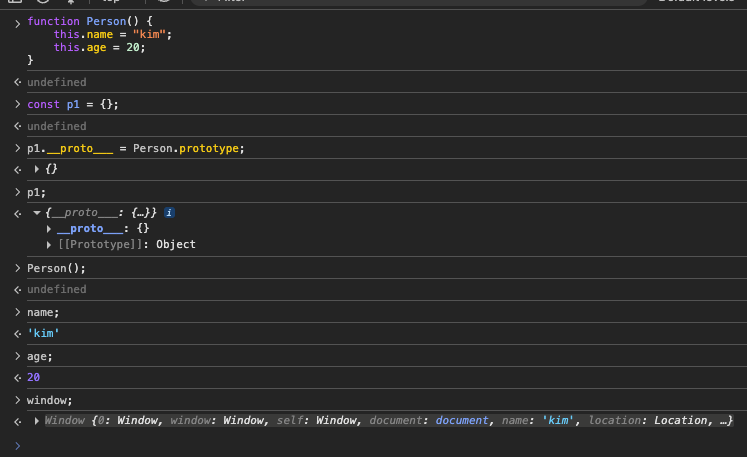

---

객체 상속
1. 프로토타입(prototype)기반의 객체간의 상속(프로토타입 체인)
2. 상속: 객체와 객체를 연결

`console.dir()`로 prototype 확인 가능

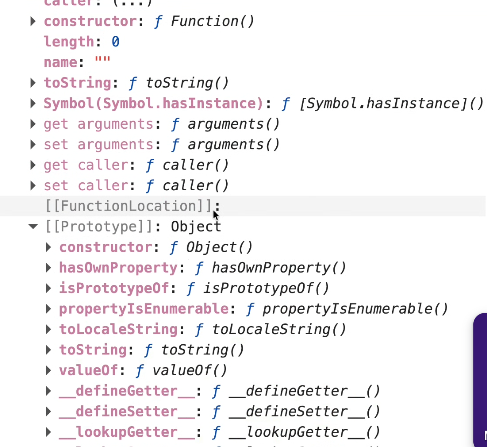

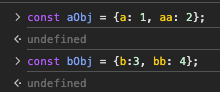


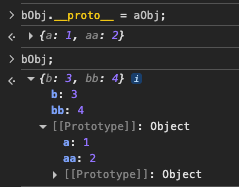

```javascript
obj.__proto__ = parentObjl //자식 obj에 parentObj 상속

```

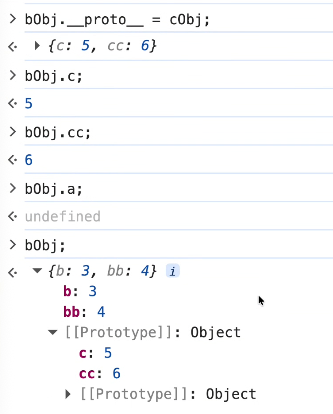
- 부모가 cObj로 바뀌면 aObj는 더이상 b0bj에서 바뀔 수 없음

### 1. 객체를 생성하는 세 가지 방법

#### 1.1 객체 생성 방식별 문법과 코드 예시

객체 리터럴

생성자 함수

#### 1.2 메서드 선언과 메모리 문제, 그리고 클래스 구문 도입 배경

생성자 내부 선언의 문제점

프로토타입 객체 정의를 통한 해결

클래스 구문의 도입과 문법적 편의성

### 2. 프로토타입과 프로토타입 체인의 동작 방식 

#### 2.1 내부 프로퍼티 [[Prototype]]과 __proto__의 역할

- [[Prototype]]
- \_\_proto\_\_

#### 2.2 프로토타입 체인을 통한 데이터 탐색

탐색 메커니즘

#### 2.3 new 연산자 호출 시 4단계 내부 과정

### 3. 생성자 함수와 클래스를 활용한 상속

#### 3.1 생성자 함수 기반의 상속과 프로토타입 연결
- 생성자 빌려오기 (call)
- 프로토타입 명시적 연결

#### 3.2 클래스(Class) 구문 기반의 상속과 super 활용

기존 프로토타입 기반 동작을 더 읽기 쉬운 class 문법으로 표현 --> "syntatic sugar"

js class는 python class와 다름 (사실상 js에서 class는 존재하지 않음)

```javascript
class Person {
    constructor(name, age) {
        this.name = name;
        this.age = age;
    }

    showInfo() {
        console.log(this.name, this.age);
    }

    static sayHello() { // 정적 메소드
        console.log("안녕하세요!"); 
    }
    
}

Person.sayHello(); // 안녕하세요!

const p1 = new Person("kim", 20);
p1; // Person {name: "kim", age: 20}
p1.showInfo(); // Kim 20
console.dir(Person);
```

console.dir(Person); 결과

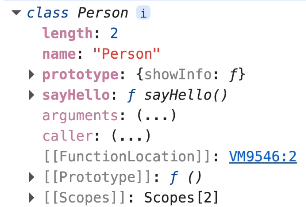

- showInfo: instance method. p1 한 명의 정보
- sayHello: static. 공통 도구 기능(모든 Person에 공통인 기능)

In [ ]:
// 부모 클래스 선언
class Ellipse {
    constructor(a, b) {
        this.a = a;
        this.b = b;
    }

    getArea() {
        return Math.PI * this.a * this.b;
    }
}

// 자식 클래스 선언 (위의 CircleInherit 생성자 함수 구조를 클래스로 변환)
class Circle extends Ellipse {
    constructor(r) {
        // 부모 생성자를 호출하여 가로, 세로 규격을 반지름 r로 동일하게 초기화합니다.
        super(r, r); 
    }

    // 부모의 getArea 메서드를 오버라이딩(재정의)하면서 부모의 로직을 재사용
    getArea() {
        console.log("재정의된 getArea()");
        return super.getArea();
    }
}

const c = new Circle(5);
console.log("클래스 상속 - 결과:", c.getArea());

반지름이 5인 원의 넓이를 클래스로 계산합니다.
클래스 상속 - 결과: 78.53981633974483


In [ ]:
function Ellipse(a, b) {
  this.a = a; // "이 타원"의 가로 반지름
  this.b = b; // "이 타원"의 세로 반지름
}

Ellipse.prototype.getArea = function() {
  return this.a * this.b * Math.PI;
  // 이 타원의 넓이 = 가로 반지름 × 세로 반지름 × π
};

function Circle(r) {
    Ellipse.apply(this, [r, r]);
  // Circle도 Ellipse에게 “나를 a=r, b=r인 타원으로 만들어 줘!”라고 부탁해요.
  // 그래서 원은 가로와 세로 반지름이 똑같은 타원이 됩니다.
}

In [ ]:
Circle.prototype = Ellipse.prototype; // 이 방법으로 하면 안됨

In [8]:
Circle.prototype = Object.create(Ellipse.prototype, {
    constructor: {
        value: Circle
    }
});

const c1 = new Circle(5);
c1.getArea();

78.53981633974483


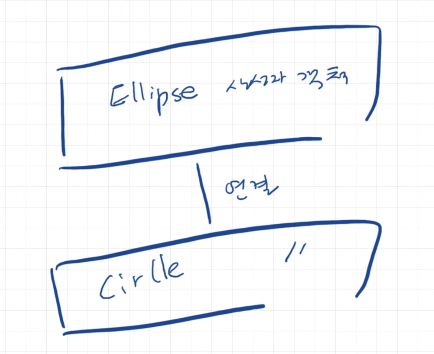

연결관계라 상속이 많아지면 계산 시간 증가, 성능 저하 가능

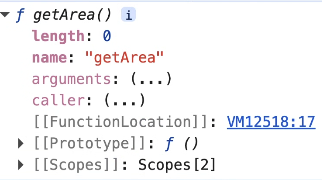
- class 안에 정의된 함수 객체는 prototype이 정해지지 않은 제한된 기능을 가짐

### 4. 프로퍼티 속성 제어와 객체 잠금

#### 4.1 데이터 프로퍼티와 접근자 프로퍼티의 구분

* 마지막 콤마 붙이는 것이 관례
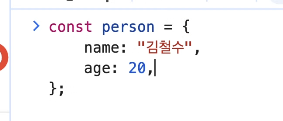

데이터 프로퍼티

- value: 값
- writable: 값 변경 가능 여부
- enumerable: 열거 가능 여부
- configurable: 설정값 (value, writable 등) 재정의 가능 여부 (설정값 재정의 가능한가?)
  - false -> 삭제도 불가

In [18]:
const person = {
    name: "김철수",
    age: 20
};

Object.getOwnPropertyDescriptors(person); /// key 값 속성 조회

Object.defineProperty(person); // 속성 설정값 하나 변경

8:8 - Expected 3 arguments, but got 1.


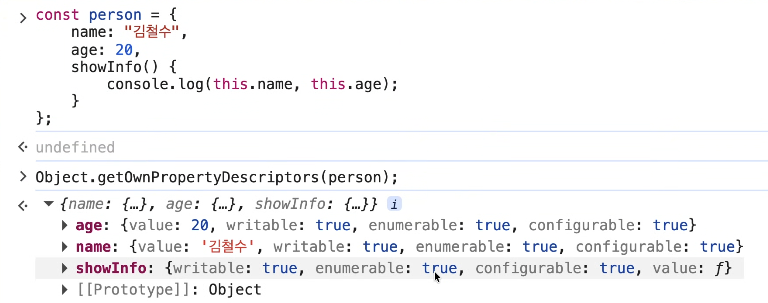

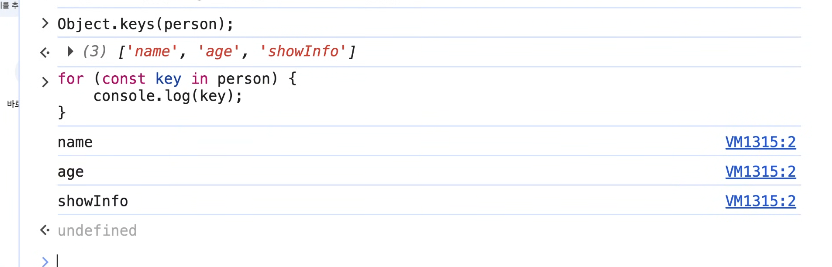
- enumerable=true인 key만 for문 출력

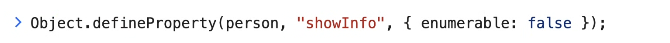
- 속성값 바꿔주기

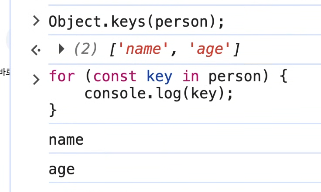
- 다시 key값을 조회하면 showInfo의 enumerable=false이므로 showInfo만 조회되지 않음

---

접근자 프로퍼티

- `get func` : 읽기
- `set func` : 쓰기
- `enumerable` : 열거가능여부
- `configurable` : 

In [22]:
const person = {
  _name: "김철수", // 실제 이름을 보관하는 칸
  _age: 20,        // 실제 나이를 보관하는 칸

    get name() {
        console.log("get name():");
        return this._name;
        // person.name이라고 읽으면 실행돼요.
    },

    set name(name) {
        console.log("set name():");
        this._name = name;
        // person.name = "영희"처럼 바꾸면 실행돼요.
    },

    get age() {
        return this._age;
        // person.age라고 읽으면 실행돼요.
    },

    set age(age) {
        this._age = age;
        // person.age = 21처럼 바꾸면 실행돼요.
    }
};

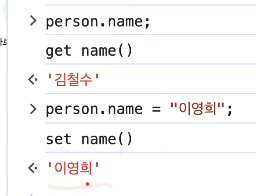

-> 위 코드는 통제가 되고 있지 않는 상태 (value 임의로 바꾸기 가능한 상태임)

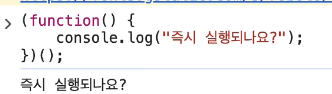
- 즉시 실행함수

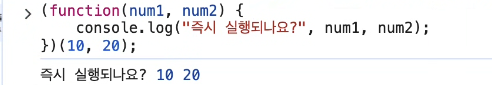

외부에서 value값을 임의로 바꾸지 못하도록 통제하는 법

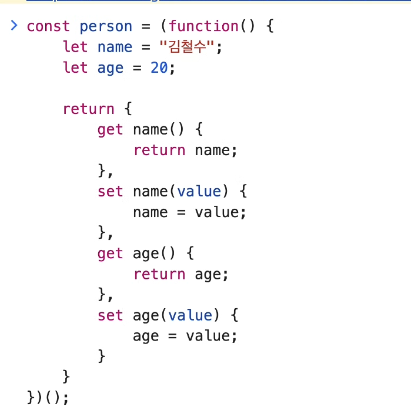

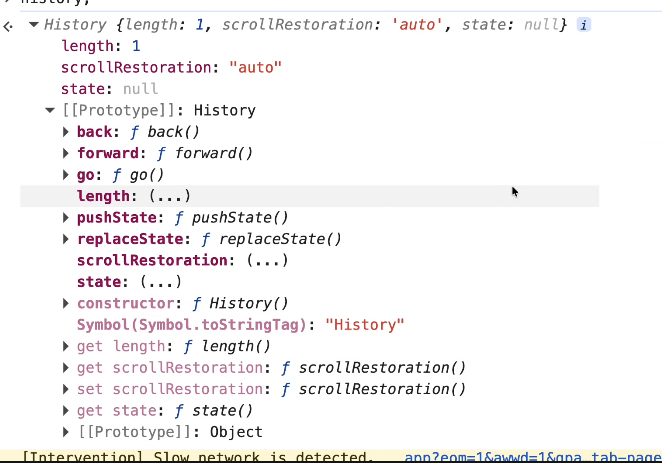

#### 4.2 프로퍼티 디스크립터 조회: Object.getOwnPropertyDescriptor

#### 4.3 프로퍼티 3대 핵심 속성과 Object.defineProperty

#### 4.4 객체 수정 방지를 위한 3단계 잠금 메서드

https://developer.mozilla.org/ko/docs/Web/JavaScript/Reference/Global_Objects/Object/freeze

확장 방지 (Object.preventExtensions)
- 속성 추가 차단(객체의 장래 확장을 막음)

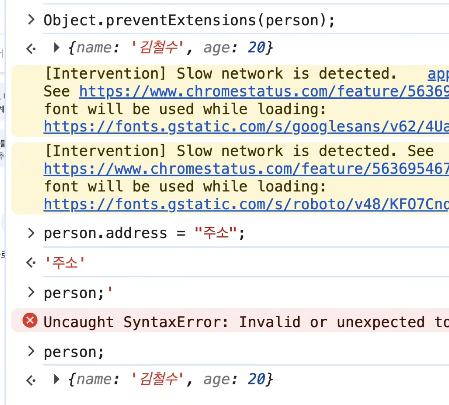

밀봉 (Object.seal) : 구조 변경 차단
- 속성 추가, 삭제 불가
- 속성 변경 가능
- configurable: false;

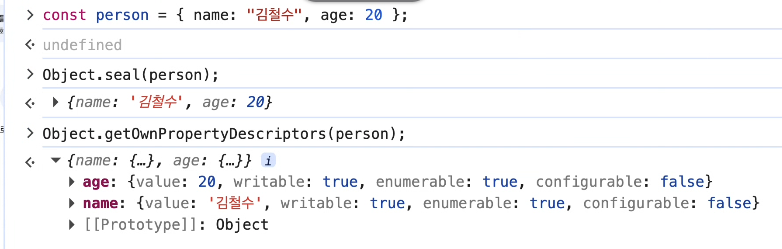

동결 (Object.freeze) : 모든 수정 차단
- 속성 추가, 삭제, 변경 불가
- 조회만 가능

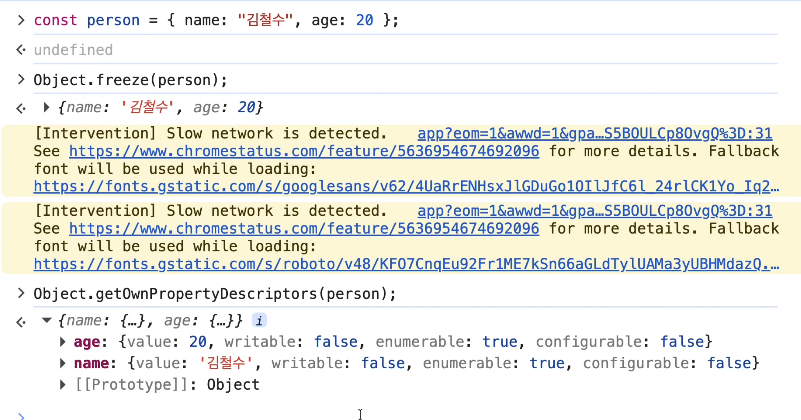

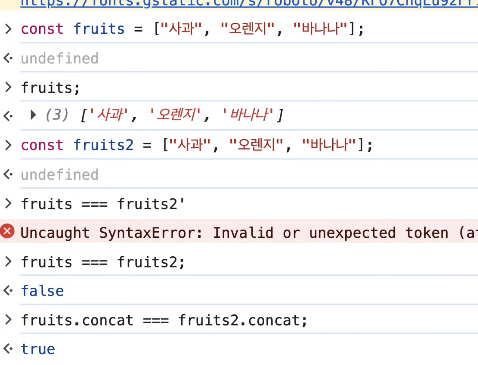

### 5. 데이터 직렬화와 JSON을 활용한 깊은 복사

직렬화(Serialization)
- 전송가능한 형태로 변환 (문자열) - JSON 문자열
- 함수, undefined => 변환불가 (null)

JSON Object
- 자바스크립트 객체 -> JSON 문자열 (직렬화)
  - `stringfy(...)`
  - stringfy -> type= string
- JSON 문자열 -> 자바스크립트 객체(역직렬화)
  - `parse(...)`

#### 5.1 JSON 포맷의 데이터 타입 규칙과 변환
- 표기 규칙

JSON.stringify()

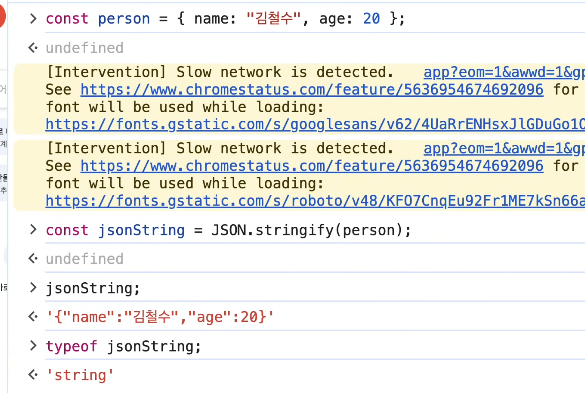

JSON.parse()

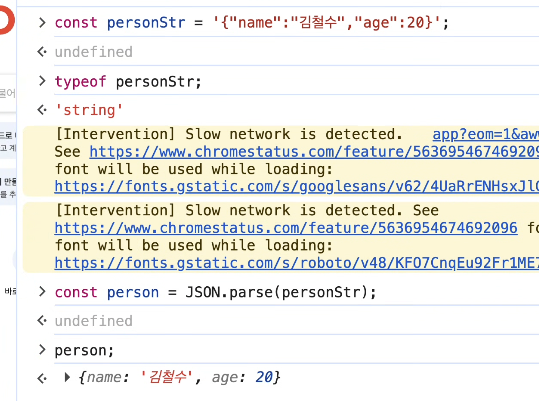

#### 5.2 객체의 깊은 복사

- 얕은 복사: 주소만 복사
  - 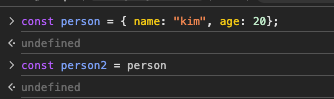

- 깊은 복사: 새로운 객체 + 내용도 복사 
  - 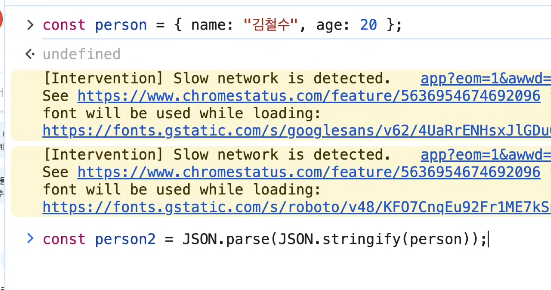
  - 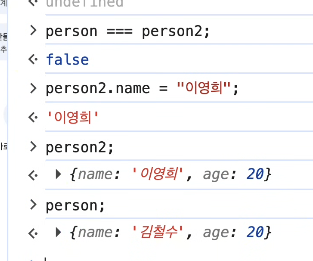

In [ ]:
const stageInfo = {
    stageName: "용암지대",
    monsters: { elite: "드래곤", normal: "슬라임" } // 중첩 구조
};

// JSON 문자열 변환 후 파싱을 수행하여 독립된 복사본 객체를 생성합니다.
const deepCloneStage = JSON.parse(JSON.stringify(stageInfo));

// 복사본 객체 내부의 데이터를 변경합니다.
deepCloneStage.monsters.elite = "오우거";

// 원본과 복사본의 내부 상태를 비교하여 검증합니다.
console.log("원본 엘리트 몬스터:", stageInfo.monsters.elite);    // "드래곤" 유지
console.log("복사본 엘리트 몬스터:", deepCloneStage.monsters.elite); // "오우거" 변경 확인